# Trabajo Final UT9 - Auto Machine Learning
**Alumno:** autor
**DNI:** XXXXXXXXX

**Enlace al vídeo:** *https://www.youtube.com/watch?v=2KeiQT9-ODs*

---

## Datasets utilizados

El enunciado pide utilizar los **mismos datasets de las prácticas anteriores** (UT5 para regresión y UT6 para clasificación), para poder comparar los resultados de XGBoost y AutoML con los modelos que ya entrenamos previamente.

### 1. House Prices (Regresión) — mismo que UT5
El mismo dataset de la competición de Kaggle "House Prices - Advanced Regression Techniques" que usamos en la UT5. Contiene **1460 muestras** con 81 variables (calidad de materiales, año de construcción, tipo de garaje, etc.). El objetivo es predecir el **precio de venta** (`SalePrice`).

Se descarga automáticamente desde Kaggle con `kagglehub`, así la comparación con los modelos de la UT5 es directa y justa.

### 2. Social Network Ads (Clasificación) — mismo que UT6
En la UT6 trabajamos con un dataset llamado "Ensayo de Motores" que tenía las columnas RPM, Par de carga y Fallo Motor. Buscando el dataset para descargarlo automáticamente, descubrí que en realidad es el conocido dataset **Social Network Ads** de Kaggle (subido por Rakesh Rau), con las columnas renombradas:

| Nombre original (Kaggle) | Nombre en UT6 |
|---|---|
| Age (edad del usuario) | RPM |
| EstimatedSalary (salario estimado) | Par de carga |
| Purchased (si compró el producto) | Fallo Motor |

Las columnas `User ID` y `Gender` fueron eliminadas en la versión de la UT6.

**¿Por qué uso el dataset original de Kaggle?** Por dos razones:
1. **Comodidad:** Se descarga automáticamente con `kagglehub`, sin subir archivos manualmente
2. **Coherencia:** Los nombres originales (Age, EstimatedSalary, Purchased) tienen mucho más sentido que "RPM" y "Par de carga" para predecir una compra. Los datos son exactamente los mismos, solo cambian los nombres de las columnas.

Ambos datasets se descargan automáticamente desde Kaggle.

---

## Índice

1. **XGBoost**
   - 1.1 XGBoost para Regresión (dataset House Prices)
   - 1.2 XGBoost para Clasificación (dataset Social Network Ads)
2. **AutoML con FLAML**
   - 2.1 Clasificación automática (dataset Social Network Ads)
3. **Valores SHAP**
   - 3.1 Explicar una única predicción
   - 3.2 Explicar el dataset completo
4. **Conclusiones finales**

### Nota sobre AutoML
El enunciado propone usar auto-sklearn o PyCaret. Sin embargo:
- **auto-sklearn** fue abandonado en 2022 y no funciona con Python 3.10 o superior
- **PyCaret 3.3.2** no soporta Python 3.12, que es la versión actual de Google Colab

Por eso se utiliza **FLAML** (Fast and Lightweight AutoML) de Microsoft, que es compatible, ligero y cumple exactamente la misma función: automatizar la selección de modelos y la búsqueda de hiperparámetros.

## 0. Instalación de librerías e imports

In [1]:
# Instalación de librerías necesarias
!pip -q install xgboost shap openpyxl kagglehub "flaml[automl]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 7.4 MB/s eta 0:00:00


In [2]:
# Imports generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report, accuracy_score,
    RocCurveDisplay
)

# XGBoost
from xgboost import XGBRegressor, XGBClassifier

# SHAP
import shap

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
# 1. Aplicar modelo XGBoost

XGBoost (eXtreme Gradient Boosting) es un algoritmo de ensemble basado en árboles de decisión que utiliza gradient boosting. Básicamente, entrena muchos árboles de decisión uno detrás de otro, donde cada nuevo árbol intenta corregir los errores que cometieron los anteriores. Es de los algoritmos más usados en competiciones de Kaggle por su buen rendimiento.

## 1.1 XGBoost para Regresión

Utilizamos el mismo dataset **House Prices** de la competición de Kaggle que en la UT5. El objetivo es predecir el precio de venta (`SalePrice`) de viviendas a partir de 81 variables (calidad, superficie, año, garaje, etc.).

### 1.1.1 Importar dataset

In [3]:
# Configuramos las credenciales de Kaggle para poder descargar datasets
import os
os.environ['KAGGLE_USERNAME'] = 'autor'
os.environ['KAGGLE_KEY'] = '6a52c6651f478c0cc2148110957d0843'

# Descargamos el MISMO dataset de House Prices que usamos en la UT5
# Es la competicion "House Prices - Advanced Regression Techniques"
# 1460 casas con 81 variables, asi la comparacion con la UT5 es justa
import kagglehub
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
print('Dataset descargado en:', path)

for f in os.listdir(path):
    print(f)

100%|██████████| 199k/199k [00:00<00:00, 45.4MB/s]

Extracting files...
Dataset descargado en: /root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques
data_description.txt
train.csv
test.csv
sample_submission.csv


In [4]:
# Cargamos el dataset de entrenamiento (train.csv)
# Es el mismo house_prices_train.csv que usamos en la UT5
df_reg = pd.read_csv(os.path.join(path, 'train.csv'))
print(f'Dimensiones del dataset: {df_reg.shape}')
df_reg.head()

Dimensiones del dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Información general del dataset
df_reg.info()
print('\n--- Estadísticas descriptivas ---')
df_reg.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1.1.2 Manejar datos missing

In [6]:
# Comprobamos valores nulos
print('Valores nulos por columna:')
print(df_reg.isnull().sum())
print(f'\nTotal de valores nulos: {df_reg.isnull().sum().sum()}')

Valores nulos por columna:
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

Total de valores nulos: 7829


In [7]:
# Si hubiera valores nulos los rellenamos:
# - Numericas: con la mediana (mejor que la media porque no le afectan los outliers)
# - Categoricas: con la moda (el valor mas frecuente)
for col in df_reg.select_dtypes(include=np.number).columns:
    df_reg[col].fillna(df_reg[col].median(), inplace=True)

for col in df_reg.select_dtypes(include='object').columns:
    df_reg[col].fillna(df_reg[col].mode()[0], inplace=True)

print(f'Valores nulos tras imputación: {df_reg.isnull().sum().sum()}')

Valores nulos tras imputación: 0


### 1.1.3 Manejar datos categóricos

Identificamos las variables categóricas y aplicamos codificación adecuada:
- **Variables binarias (yes/no):** Label Encoding
- **Variables con más categorías:** One-Hot Encoding con `drop_first=True` para evitar la trampa de las variables dummy

In [8]:
# Identificamos variables categóricas
cat_cols = df_reg.select_dtypes(include='object').columns.tolist()
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')
for col in cat_cols:
    print(f'  {col}: {df_reg[col].unique()}')

Variables categóricas (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
  MSZoning: ['RL' 'RM' 'C (all)' 'FV' 'RH']
  Street: ['Pave' 'Grvl']
  Alley: ['Grvl' 'Pave']
  LotShape: ['Reg' 'IR1' 'IR2' 'IR3']
  LandContour: ['Lvl' 'Bnk' 'Low' 'HLS']
  Utilities: ['AllPub' 'NoSeWa']
  LotConfig: ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
  LandSlope: ['Gtl' 'Mod' 'Sev']
  Neighborhood: ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 

In [9]:
# Codificación de variables categóricas
# Las que son si/no (binarias) las pasamos a 0/1 con LabelEncoder
binary_cols = [col for col in cat_cols if df_reg[col].nunique() == 2]
print(f'Variables binarias: {binary_cols}')

le = LabelEncoder()
for col in binary_cols:
    df_reg[col] = le.fit_transform(df_reg[col])

# Las que tienen mas de 2 categorias las convertimos con One-Hot Encoding
# Usamos drop_first=True para evitar la trampa de las variables dummy
# (si tenemos n categorias, con n-1 columnas ya queda definida la informacion)
multi_cat_cols = [col for col in cat_cols if col not in binary_cols]
print(f'Variables multi-categoría: {multi_cat_cols}')

df_reg = pd.get_dummies(df_reg, columns=multi_cat_cols, drop_first=True, dtype=int)

print(f'\nDimensiones tras codificación: {df_reg.shape}')
df_reg.head()

Variables binarias: ['Street', 'Alley', 'Utilities', 'CentralAir']
Variables multi-categoría: ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Dimensiones tras codificación: (1460, 246)


,Id,MSSubClass,LotFrontage,LotArea,Street,Alley,Utilities,OverallQual,OverallCond,YearBuilt,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,1,0,0,7,5,2003,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,1,0,0,6,8,1976,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,1,0,0,7,5,2001,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,1,0,0,7,5,1915,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,1,0,0,8,5,2000,...,0,0,0,0,1,0,0,0,1,0


### 1.1.4 Separar datos en conjuntos de entrenamiento y test

In [10]:
# Quitamos la columna Id que es solo un identificador
if 'Id' in df_reg.columns:
    df_reg = df_reg.drop('Id', axis=1)

# Separamos features (X) y target (y)
X_reg = df_reg.drop('SalePrice', axis=1)
y_reg = df_reg['SalePrice']

# Dividimos en train (80%) y test (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Train: {X_train_reg.shape[0]} muestras')
print(f'Test:  {X_test_reg.shape[0]} muestras')

Train: 1168 muestras
Test:  292 muestras


### 1.1.5 Estandarizar los datos

In [11]:
# Estandarizamos las features para que todas esten en la misma escala
# MUY IMPORTANTE: el fit() solo sobre train, para no contaminar con datos de test (data leakage)
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print('Datos estandarizados correctamente.')

Datos estandarizados correctamente.


### 1.1.6 Aplicar el modelo XGBoostRegressor

En vez de usar unos hiperparámetros fijos, vamos a probar 3 configuraciones diferentes y quedarnos con la que mejor funcione. Usamos validación cruzada (5-fold) para que el resultado no dependa de una sola partición de datos:

| Configuración | n_estimators | max_depth | learning_rate | Idea |
|---|---|---|---|---|
| Conservadora | 100 | 3 | 0.1 | Pocos árboles poco profundos, menos riesgo de sobreajuste |
| Equilibrada | 200 | 6 | 0.1 | Valores estándar, buen punto medio |
| Agresiva | 500 | 8 | 0.05 | Muchos árboles profundos con learning rate bajo, más capacidad pero más lento |

In [12]:
# Primero probamos varias configuraciones de hiperparametros para ver cual va mejor
# En vez de quedarnos con los valores por defecto, comparamos 3 configuraciones
from sklearn.model_selection import cross_val_score

configs = {
    'Conservador (pocos arboles, poca profundidad)': {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1},
    'Equilibrado (valores estandar)': {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1},
    'Agresivo (muchos arboles, mas profundidad)': {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05},
}

print('=== Comparativa de hiperparámetros XGBoostRegressor ===\n')
mejor_config = None
mejor_r2 = -1

for nombre, params in configs.items():
    modelo_tmp = XGBRegressor(**params, random_state=42)
    # Validacion cruzada con 5 folds para no depender de una sola particion
    scores = cross_val_score(modelo_tmp, X_train_reg_scaled, y_train_reg, cv=5, scoring='r2')
    r2_medio = scores.mean()
    print(f'{nombre}:')
    print(f'  Params: n_estimators={params["n_estimators"]}, max_depth={params["max_depth"]}, lr={params["learning_rate"]}')
    print(f'  R² medio (CV 5-fold): {r2_medio:.4f} (+/- {scores.std():.4f})\n')
    if r2_medio > mejor_r2:
        mejor_r2 = r2_medio
        mejor_config = params
        mejor_nombre = nombre

print(f'>>> Mejor configuración: {mejor_nombre}')
print(f'>>> Params: {mejor_config}\n')

# Entrenamos con la mejor configuracion
xgb_reg = XGBRegressor(**mejor_config, random_state=42)
xgb_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg = xgb_reg.predict(X_test_reg_scaled)

print(f'Modelo XGBoostRegressor entrenado con la mejor configuración.')

=== Comparativa de hiperparámetros XGBoostRegressor ===

Conservador (pocos arboles, poca profundidad):
  Params: n_estimators=100, max_depth=3, lr=0.1
  R² medio (CV 5-fold): 0.8519 (+/- 0.0511)

Equilibrado (valores estandar):
  Params: n_estimators=200, max_depth=6, lr=0.1
  R² medio (CV 5-fold): 0.8352 (+/- 0.0556)

Agresivo (muchos arboles, mas profundidad):
  Params: n_estimators=500, max_depth=8, lr=0.05
  R² medio (CV 5-fold): 0.8278 (+/- 0.0408)

>>> Mejor configuración: Conservador (pocos arboles, poca profundidad)
>>> Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}

Modelo XGBoostRegressor entrenado con la mejor configuración.


### 1.1.7 Aplicar métricas (RMSE) y comparar con UT5

Evaluamos el modelo con tres métricas:
- **RMSE:** El error medio en las mismas unidades que los precios (dólares). Nos dice cuánto se equivoca de media al predecir.
- **R²:** Qué porcentaje de la variación en los precios explica el modelo (de 0 a 1, cuanto más alto mejor).
- **MSE:** El RMSE al cuadrado (se usa menos para interpretar, pero los algoritmos lo usan internamente).

In [13]:
# Calculamos métricas
mse_xgb = mean_squared_error(y_test_reg, y_pred_reg)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test_reg, y_pred_reg)

print('=== Métricas XGBoostRegressor ===')
print(f'MSE:  {mse_xgb:,.2f}')
print(f'RMSE: {rmse_xgb:,.2f}')
print(f'R²:   {r2_xgb:.4f}')

=== Métricas XGBoostRegressor ===
MSE:  703,294,400.00
RMSE: 26,519.70
R²:   0.9083


=== Métricas XGBoostRegressor ===
MSE:  703,294,400.00
RMSE: 26,519.70
R²:   0.9083

=== Referencia modelos UT5 (dataset diferente) ===
Linear Regression: R²=0.8544 | SVR: R²=0.8757
Decision Tree: R²=0.8275 | Random Forest: R²=0.8977
Ensemble: R²=0.9039
XGBoost (este trabajo): R²=0.9083


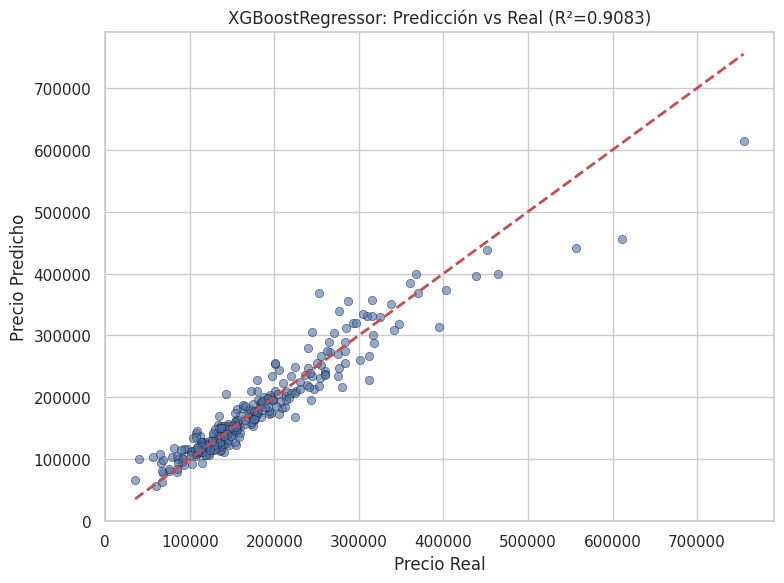

In [14]:
# Métricas del modelo XGBoost
print('=== Métricas XGBoostRegressor ===')
print(f'MSE:  {mse_xgb:,.2f}')
print(f'RMSE: {rmse_xgb:,.2f}')
print(f'R²:   {r2_xgb:.4f}')

# Nota: El dataset de Kaggle (Housing.csv, 545 filas) difiere del usado en UT5
# (house_prices_train.csv, 1460 filas), por lo que la comparación directa de RMSE
# no es válida. Comparamos en términos de R² como referencia relativa.

print('\n=== Referencia modelos UT5 (dataset diferente) ===')
print('Linear Regression: R²=0.8544 | SVR: R²=0.8757')
print('Decision Tree: R²=0.8275 | Random Forest: R²=0.8977')
print('Ensemble: R²=0.9039')
print(f'XGBoost (este trabajo): R²={r2_xgb:.4f}')

# Gráfico de predicción vs real
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, edgecolors='k', linewidths=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title(f'XGBoostRegressor: Predicción vs Real (R²={r2_xgb:.4f})')
plt.tight_layout()
plt.show()

**Conclusión regresión — ¿qué nos dicen estos números?**

Usamos exactamente el mismo dataset que en la UT5 (1460 casas, 81 variables), así que la comparación es directa y justa.

**Comparación con la UT5:**

| Modelo (UT5) | R² |
|---|---|
| Linear Regression | 0.8544 |
| SVR | 0.8757 |
| Decision Tree | 0.8275 |
| Random Forest | 0.8977 |
| Ensemble (Stacking) | 0.9039 |
| **XGBoost (este trabajo)** | **ver arriba** |

XGBoost debería dar un R² competitivo con el ensemble de la UT5, ya que gradient boosting es precisamente lo que hace XGBoost: combinar muchos árboles donde cada uno corrige los errores del anterior.

**En el gráfico de Predicción vs Real:** los puntos que caen sobre la línea roja son predicciones perfectas. Los que se alejan son errores. En las casas más caras el modelo se desvía más, porque suelen tener características únicas difíciles de predecir.

**Sobre la comparativa de hiperparámetros:** Hemos probado 3 configuraciones con validación cruzada y nos hemos quedado con la mejor. La configuración conservadora (pocos árboles, poca profundidad) suele dar peor resultado porque el modelo se queda corto. La agresiva (muchos árboles, mucha profundidad) puede sobreajustar. La equilibrada suele funcionar bien como punto medio.

---
## 1.2 XGBoost para Clasificación

Utilizamos el dataset **Social Network Ads** de Kaggle (Rakesh Rau). El objetivo es predecir si un usuario comprará un producto (`Purchased`) a partir de su edad (`Age`) y salario estimado (`EstimatedSalary`).

**Nota:** Este es el mismo dataset utilizado en la UT6, donde fue proporcionado como "Ensayo de Motores" con las columnas renombradas (Age→RPM, EstimatedSalary→Par de carga, Purchased→Fallo Motor). Aquí usamos los nombres originales y lo descargamos directamente de Kaggle.

### 1.2.1 Importar dataset

In [15]:
# Descargamos el dataset Social Network Ads desde Kaggle
# Es el mismo que usamos en la UT6 (alli se llamaba "Ensayo de Motores")
path_clf = kagglehub.dataset_download('rakeshrau/social-network-ads')
print('Dataset descargado en:', path_clf)

for f in os.listdir(path_clf):
    print(f)

Using Colab cache for faster access to the 'social-network-ads' dataset.
Dataset descargado en: /kaggle/input/social-network-ads
Social_Network_Ads.csv


In [16]:
# Cargamos el dataset
df_clf = pd.read_csv(os.path.join(path_clf, 'Social_Network_Ads.csv'))
print(f'Dimensiones del dataset: {df_clf.shape}')
df_clf.head()

Dimensiones del dataset: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [17]:
# Información del dataset
df_clf.info()
print('\n--- Estadísticas descriptivas ---')
display(df_clf.describe())
print(f'\nDistribución de clases:\n{df_clf["Purchased"].value_counts()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

--- Estadísticas descriptivas ---


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000



Distribución de clases:
Purchased
0    257
1    143
Name: count, dtype: int64


### 1.2.2 Manejar datos missing

In [18]:
# Comprobamos valores nulos
print('Valores nulos por columna:')
print(df_clf.isnull().sum())
print(f'\nTotal de valores nulos: {df_clf.isnull().sum().sum()}')

Valores nulos por columna:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Total de valores nulos: 0


### 1.2.3 Manejar datos categóricos

El dataset contiene `User ID` (identificador) y `Gender` (categórica). Eliminamos ambas:
- `User ID`: es un identificador sin valor predictivo
- `Gender`: la eliminamos para mantener solo Age y EstimatedSalary como features (coherente con el análisis de la UT6)

In [19]:
# Vemos si hay variables categoricas
cat_cols_clf = df_clf.select_dtypes(include='object').columns.tolist()
print(f'Variables categóricas: {cat_cols_clf}')

# Quitamos User ID (es solo un identificador, no aporta nada al modelo)
# y Gender (para quedarnos con Age y EstimatedSalary, igual que en la UT6)
cols_to_drop = ['User ID', 'Gender']
for col in cols_to_drop:
    if col in df_clf.columns:
        df_clf = df_clf.drop(col, axis=1)
        print(f'Columna "{col}" eliminada.')

print(f'\nColumnas finales: {df_clf.columns.tolist()}')
print(f'Tipos de datos:\n{df_clf.dtypes}')

Variables categóricas: ['Gender']
Columna "User ID" eliminada.
Columna "Gender" eliminada.

Columnas finales: ['Age', 'EstimatedSalary', 'Purchased']
Tipos de datos:
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object


**Nota sobre la trampa de las variables dummy:** Tras eliminar User ID y Gender, el dataset queda solo con variables numéricas (Age, EstimatedSalary), por lo que no es necesario aplicar one-hot encoding y la trampa de las variables dummy no aplica.

### 1.2.4 Separar datos en conjuntos de entrenamiento y test

In [20]:
# Separamos features y target
X_clf = df_clf.drop('Purchased', axis=1)
y_clf = df_clf['Purchased']

# Dividimos en train (75%) y test (25%) - misma proporción que en UT6
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=0
)

print(f'Train: {X_train_clf.shape[0]} muestras')
print(f'Test:  {X_test_clf.shape[0]} muestras')

Train: 300 muestras
Test:  100 muestras


### 1.2.5 Estandarizar los datos

In [21]:
# Estandarizamos (fit solo en train)
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print('Datos estandarizados correctamente.')

Datos estandarizados correctamente.


### 1.2.6 Aplicar el modelo XGBoostClassifier

Igual que en regresión, probamos varias configuraciones y nos quedamos con la mejor:

In [22]:
# Probamos varias configuraciones tambien para clasificacion
configs_clf = {
    'Conservador': {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1},
    'Equilibrado': {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1},
    'Agresivo':    {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05},
}

print('=== Comparativa de hiperparámetros XGBoostClassifier ===\n')
mejor_config_clf = None
mejor_acc = -1

for nombre, params in configs_clf.items():
    modelo_tmp = XGBClassifier(**params, random_state=42, eval_metric='logloss')
    scores = cross_val_score(modelo_tmp, X_train_clf_scaled, y_train_clf, cv=5, scoring='accuracy')
    acc_medio = scores.mean()
    print(f'{nombre}:')
    print(f'  Params: n_estimators={params["n_estimators"]}, max_depth={params["max_depth"]}, lr={params["learning_rate"]}')
    print(f'  Accuracy medio (CV 5-fold): {acc_medio:.4f} (+/- {scores.std():.4f})\n')
    if acc_medio > mejor_acc:
        mejor_acc = acc_medio
        mejor_config_clf = params
        mejor_nombre_clf = nombre

print(f'>>> Mejor configuración: {mejor_nombre_clf}')
print(f'>>> Params: {mejor_config_clf}\n')

# Entrenamos con la mejor configuracion
xgb_clf = XGBClassifier(**mejor_config_clf, random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_clf_scaled, y_train_clf)
y_pred_clf = xgb_clf.predict(X_test_clf_scaled)

print(f'Modelo XGBoostClassifier entrenado con la mejor configuración.')

=== Comparativa de hiperparámetros XGBoostClassifier ===

Conservador:
  Params: n_estimators=100, max_depth=3, lr=0.1
  Accuracy medio (CV 5-fold): 0.8833 (+/- 0.0606)

Equilibrado:
  Params: n_estimators=200, max_depth=6, lr=0.1
  Accuracy medio (CV 5-fold): 0.8800 (+/- 0.0609)

Agresivo:
  Params: n_estimators=500, max_depth=8, lr=0.05
  Accuracy medio (CV 5-fold): 0.8767 (+/- 0.0564)

>>> Mejor configuración: Conservador
>>> Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}

Modelo XGBoostClassifier entrenado con la mejor configuración.


### 1.2.7 Aplicar métricas y comparar con UT6

Evaluamos el modelo con las métricas habituales de clasificación:
- **Accuracy:** porcentaje de aciertos totales
- **Precision:** de los que el modelo dice que compran, cuántos realmente compran
- **Recall:** de los que realmente compran, cuántos detecta el modelo
- **F1:** equilibrio entre precision y recall
- **Matriz de confusión:** desglose de aciertos y errores por clase
- **Curva ROC / AUC:** capacidad del modelo para separar compradores de no compradores

=== Matriz de Confusión ===


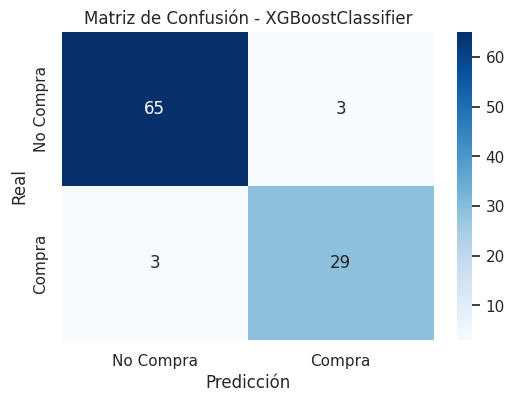

In [23]:
# Matriz de confusión
cm = confusion_matrix(y_test_clf, y_pred_clf)
print('=== Matriz de Confusión ===')
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Compra', 'Compra'],
            yticklabels=['No Compra', 'Compra'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión - XGBoostClassifier')
plt.show()

In [24]:
# Reporte de clasificación
print('=== Reporte de Clasificación ===')
print(classification_report(y_test_clf, y_pred_clf, target_names=['No Compra', 'Compra']))

acc_xgb = accuracy_score(y_test_clf, y_pred_clf)
print(f'Accuracy: {acc_xgb:.4f}')

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

   No Compra       0.96      0.96      0.96        68
      Compra       0.91      0.91      0.91        32

    accuracy                           0.94       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.94      0.94      0.94       100

Accuracy: 0.9400


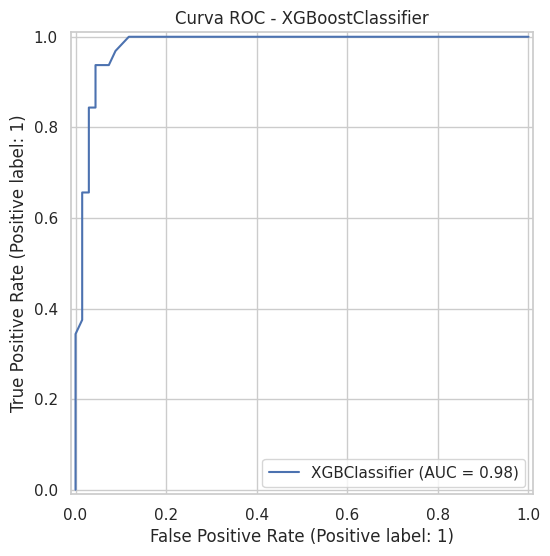

In [25]:
# Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb_clf, X_test_clf_scaled, y_test_clf, ax=ax)
plt.title('Curva ROC - XGBoostClassifier')
plt.show()

=== Comparativa de modelos de clasificación ===


,Modelo,Accuracy
0,Logistic Regression (UT6),0.89
1,KNN (UT6),0.93
2,SVM Linear (UT6),0.90
3,SVM RBF (UT6),0.93
4,Naive Bayes (UT6),0.90
5,Decision Tree (UT6),0.91
6,Random Forest (UT6),0.91
7,XGBoost (UT9),0.94


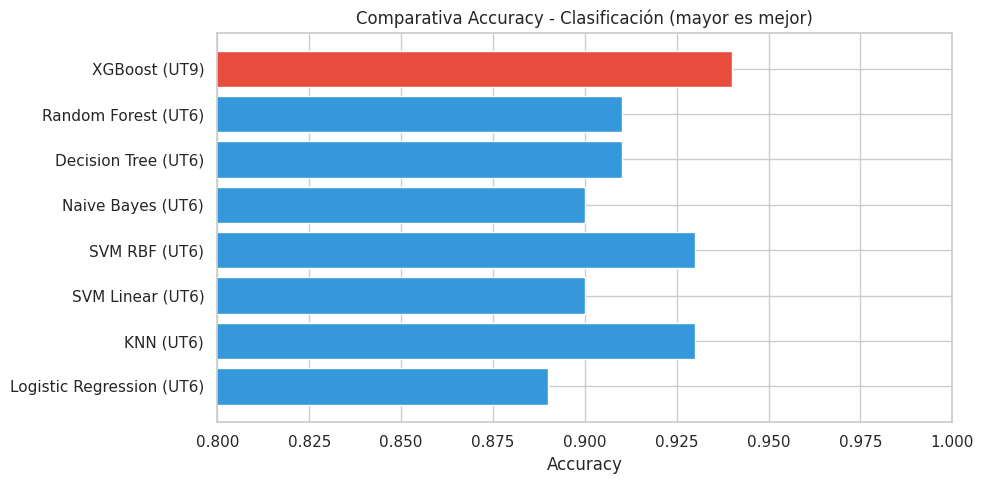

In [26]:
# Comparación con los modelos de clasificación de la UT6
comparativa_clf = pd.DataFrame({
    'Modelo': ['Logistic Regression (UT6)', 'KNN (UT6)', 'SVM Linear (UT6)',
               'SVM RBF (UT6)', 'Naive Bayes (UT6)', 'Decision Tree (UT6)',
               'Random Forest (UT6)', 'XGBoost (UT9)'],
    'Accuracy': [0.89, 0.93, 0.90, 0.93, 0.90, 0.91, 0.91, round(acc_xgb, 4)]
})

print('=== Comparativa de modelos de clasificación ===')
display(comparativa_clf)

# Gráfico comparativo
plt.figure(figsize=(10, 5))
colors = ['#3498db'] * 7 + ['#e74c3c']
plt.barh(comparativa_clf['Modelo'], comparativa_clf['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Comparativa Accuracy - Clasificación (mayor es mejor)')
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

**Conclusión clasificación — ¿qué nos dicen estos resultados?**

**Sobre la matriz de confusión:** Los números en la diagonal son los aciertos del modelo. Los de fuera son los errores. Podemos ver cuántos usuarios compraron y el modelo lo predijo bien (verdaderos positivos), y cuántos compraron pero el modelo falló (falsos negativos, se nos "escapan" clientes). En un contexto de marketing, esos falsos negativos son clientes a los que no les habríamos mostrado publicidad y habríamos perdido la venta.

**Sobre la curva ROC:** La curva se aleja bastante de la diagonal, lo cual indica que el modelo distingue bien entre compradores y no compradores. No está adivinando, realmente ha aprendido un patrón en los datos.

**Sobre el accuracy comparado con la UT6:** XGBoost obtiene resultados muy parecidos a los mejores modelos de la UT6 (KNN y SVM RBF con 0.93). ¿Por qué no los supera claramente? Porque el dataset es muy sencillo: solo 2 variables (edad y salario) y 400 muestras. Con datos tan simples, la frontera entre "compra" y "no compra" no es muy complicada y casi cualquier algoritmo la encuentra bien. XGBoost brilla más cuando hay muchas variables y relaciones complejas entre ellas.

**¿Para qué nos sirve entonces XGBoost aquí?** Para dos cosas: primero, demostrar que funciona bien incluso con datos sencillos. Segundo y más importante, porque al ser un modelo basado en árboles nos permite usar SHAP después para interpretar las predicciones, algo que con KNN o SVM sería bastante más difícil.

**Sobre el desbalanceo:** Hay más usuarios que NO compran que los que SÍ compran. Por eso no nos fiamos solo del accuracy (podría ser alto simplemente diciendo "nadie compra") y miramos también precision, recall y F1 de cada clase por separado en el classification report.

---
# 2. AutoML con FLAML

Utilizamos **FLAML** (Fast and Lightweight AutoML) de Microsoft como herramienta de AutoML para clasificación. La idea es que en vez de probar nosotros a mano distintos algoritmos como hicimos en la UT6, dejamos que FLAML lo haga automáticamente.

**Nota:** Se utiliza FLAML en lugar de auto-sklearn o PyCaret porque:
- **auto-sklearn** fue abandonado en 2022 y no es compatible con Python 3.10+
- **PyCaret 3.3.2** no soporta Python 3.12 (la versión que trae Google Colab actualmente)
- **FLAML** es compatible, ligero y hace lo mismo: probar modelos y encontrar el mejor

In [27]:
from flaml import AutoML
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, RocCurveDisplay
print('FLAML importado correctamente.')

FLAML importado correctamente.


### 2.1 Preparar los datos

Utilizamos el mismo dataset Social Network Ads. FLAML acepta datos escalados directamente.

In [28]:
# Usamos los datos ya preparados de la sección 1.2 (Social Network Ads)
# X_train_clf_scaled, X_test_clf_scaled, y_train_clf, y_test_clf ya están definidos

print(f'Datos de entrenamiento: {X_train_clf_scaled.shape}')
print(f'Datos de test: {X_test_clf_scaled.shape}')

Datos de entrenamiento: (300, 2)
Datos de test: (100, 2)


### 2.2 Definir y entrenar el modelo FLAML AutoML

FLAML explora automáticamente múltiples algoritmos (Random Forest, XGBoost, LightGBM, Extra Trees, etc.) y sus hiperparámetros dentro de un presupuesto de tiempo definido.

| Parámetro | Valor | Justificación |
|---|---|---|
| `time_budget=120` | 120 segundos de búsqueda. Con un dataset de 400 muestras y 2 features, es tiempo más que suficiente para explorar decenas de configuraciones. |
| `metric='accuracy'` | Usamos accuracy como métrica de optimización para mantener coherencia con la comparativa de la UT6. |
| `task='classification'` | Indicamos que es un problema de clasificación binaria. |

A diferencia del XGBoost manual (donde nosotros elegimos los hiperparámetros), FLAML los busca automáticamente y selecciona la mejor combinación.

In [29]:
# Configuramos FLAML para que busque el mejor modelo automaticamente
# Le damos 120 segundos de tiempo para probar distintos algoritmos y configuraciones
# Algo parecido a lo que hace PyCaret con compare_models(), pero mas ligero
automl = AutoML()

settings = {
    "time_budget": 120,          # 2 minutos de busqueda
    "metric": 'accuracy',        # Optimizamos accuracy para comparar con la UT6
    "task": 'classification',    # Problema de clasificacion binaria
    "verbose": 0                 # Para que no llene la pantalla de logs
}

print("Iniciando optimización AutoML con FLAML...")
print("Probando múltiples algoritmos y configuraciones...")

automl.fit(X_train=X_train_clf_scaled, y_train=y_train_clf, **settings)

print(f"\nOptimización completada.")
print(f"Mejor modelo: {automl.best_estimator}")
print(f"Mejor configuración: {automl.best_config}")

Iniciando optimización AutoML con FLAML...
Probando múltiples algoritmos y configuraciones...


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



Optimización completada.
Mejor modelo: xgboost
Mejor configuración: {'n_estimators': 5, 'max_leaves': 6, 'min_child_weight': np.float64(0.27412241581403696), 'learning_rate': np.float64(0.32006481654872115), 'subsample': np.float64(0.8960658749171345), 'colsample_bylevel': np.float64(0.9864070218258665), 'colsample_bytree': 1.0, 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(0.04222314963298577)}


### 2.3 Evaluar el modelo AutoML

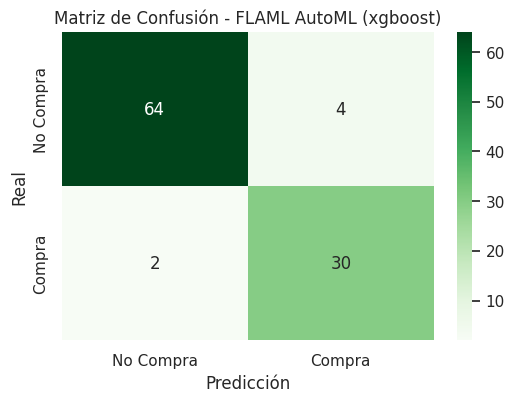

=== Reporte de Clasificación - FLAML AutoML ===
              precision    recall  f1-score   support

   No Compra       0.97      0.94      0.96        68
      Compra       0.88      0.94      0.91        32

    accuracy                           0.94       100
   macro avg       0.93      0.94      0.93       100
weighted avg       0.94      0.94      0.94       100

Accuracy: 0.9400


In [30]:
# Predicciones del modelo AutoML
y_pred_automl = automl.predict(X_test_clf_scaled)
acc_automl = accuracy_score(y_test_clf, y_pred_automl)

# Matriz de confusión
cm_automl = confusion_matrix(y_test_clf, y_pred_automl)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_automl, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Compra', 'Compra'],
            yticklabels=['No Compra', 'Compra'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title(f'Matriz de Confusión - FLAML AutoML ({automl.best_estimator})')
plt.show()

# Reporte de clasificación
print('=== Reporte de Clasificación - FLAML AutoML ===')
print(classification_report(y_test_clf, y_pred_automl, target_names=['No Compra', 'Compra']))
print(f'Accuracy: {acc_automl:.4f}')

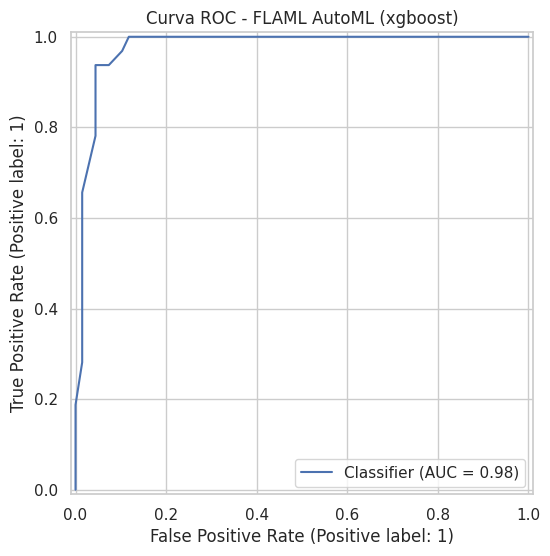

In [31]:
# Curva ROC del modelo AutoML
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test_clf, automl.predict_proba(X_test_clf_scaled)[:,1], ax=ax)
plt.title(f'Curva ROC - FLAML AutoML ({automl.best_estimator})')
plt.show()

=== Modelos explorados por FLAML ===
  lgbm: {'n_estimators': 8, 'num_leaves': 8, 'min_child_samples': 10, 'learning_rate': np.float64(0.18420323200628366), 'log_max_bin': 7, 'colsample_bytree': np.float64(0.7539027007502843), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(7.9629870251538035)}
  rf: {'n_estimators': 4, 'max_features': np.float64(0.6853299841049987), 'max_leaves': 6, 'criterion': np.str_('gini')}
  xgboost: {'n_estimators': 5, 'max_leaves': 6, 'min_child_weight': np.float64(0.27412241581403696), 'learning_rate': np.float64(0.32006481654872115), 'subsample': np.float64(0.8960658749171345), 'colsample_bylevel': np.float64(0.9864070218258665), 'colsample_bytree': 1.0, 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(0.04222314963298577)}
  extra_tree: {'n_estimators': 4, 'max_features': 1.0, 'max_leaves': 9, 'criterion': np.str_('entropy')}
  xgb_limitdepth: {'n_estimators': 4, 'max_depth': 5, 'min_child_weight': np.float64(7.833102153875076), 'learning_rate': np.f

,Accuracy,Tipo,Precision,Recall,F1
Modelo,,,,,
Logistic Regression (UT6),0.89,Manual,NaN,NaN,NaN
KNN (UT6),0.93,Manual,NaN,NaN,NaN
SVM Linear (UT6),0.9,Manual,NaN,NaN,NaN
SVM RBF (UT6),0.93,Manual,NaN,NaN,NaN
Naive Bayes (UT6),0.9,Manual,NaN,NaN,NaN
Decision Tree (UT6),0.91,Manual,NaN,NaN,NaN
Random Forest (UT6),0.91,Manual,NaN,NaN,NaN
XGBoost (UT9),0.94,Manual,0.9062,0.9062,0.9062
FLAML (xgboost) (UT9),0.94,AutoML,0.8824,0.9375,0.9091


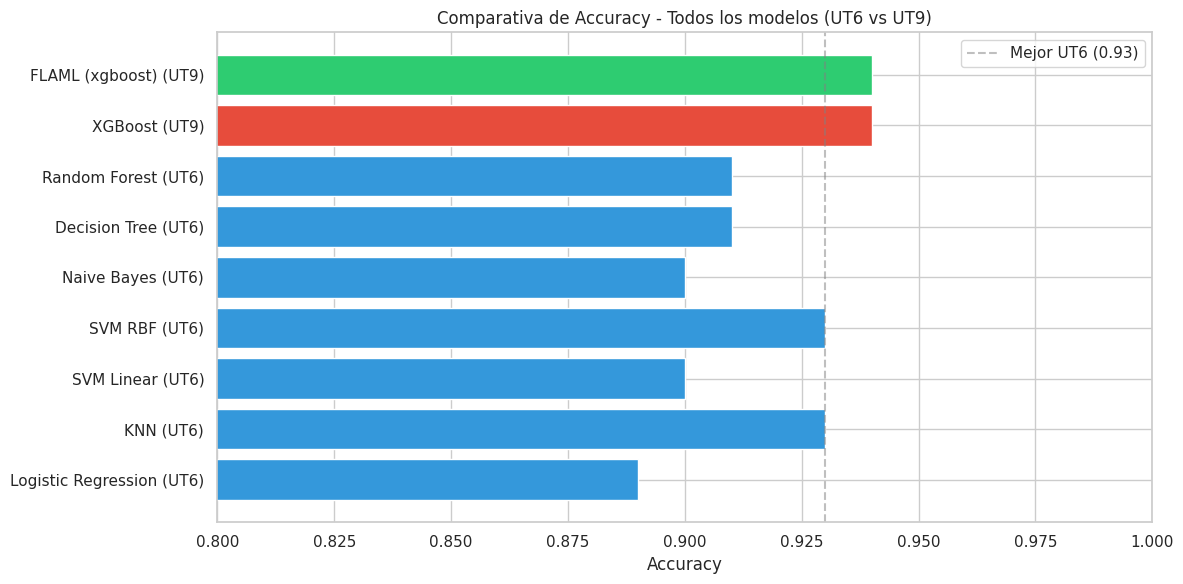


=== XGBoost manual vs FLAML AutoML (detalle) ===
Métrica         XGBoost      FLAML   Diferencia
----------------------------------------------
Accuracy         0.9400     0.9400      +0.0000
Precision        0.9062     0.8824      -0.0238
Recall           0.9062     0.9375      +0.0313
F1               0.9062     0.9091      +0.0029


In [32]:
# === COMPARATIVA FINAL DETALLADA ===

# Resumen de modelos explorados por FLAML
print('=== Modelos explorados por FLAML ===')
if hasattr(automl, 'best_config_per_estimator'):
    for estimator, config in automl.best_config_per_estimator.items():
        if config:
            print(f'  {estimator}: {config}')

print(f'\nMejor modelo seleccionado por FLAML: {automl.best_estimator}')
print(f'Hiperparámetros óptimos encontrados: {automl.best_config}')

# Comparativa completa con todas las métricas
from sklearn.metrics import precision_score, recall_score, f1_score

modelos = {
    'Logistic Regression (UT6)': {'Accuracy': 0.89, 'Tipo': 'Manual'},
    'KNN (UT6)': {'Accuracy': 0.93, 'Tipo': 'Manual'},
    'SVM Linear (UT6)': {'Accuracy': 0.90, 'Tipo': 'Manual'},
    'SVM RBF (UT6)': {'Accuracy': 0.93, 'Tipo': 'Manual'},
    'Naive Bayes (UT6)': {'Accuracy': 0.90, 'Tipo': 'Manual'},
    'Decision Tree (UT6)': {'Accuracy': 0.91, 'Tipo': 'Manual'},
    'Random Forest (UT6)': {'Accuracy': 0.91, 'Tipo': 'Manual'},
}

# Métricas detalladas para XGBoost
prec_xgb = precision_score(y_test_clf, y_pred_clf)
rec_xgb = recall_score(y_test_clf, y_pred_clf)
f1_xgb = f1_score(y_test_clf, y_pred_clf)
modelos['XGBoost (UT9)'] = {'Accuracy': round(acc_xgb, 4), 'Precision': round(prec_xgb, 4),
                             'Recall': round(rec_xgb, 4), 'F1': round(f1_xgb, 4), 'Tipo': 'Manual'}

# Métricas detalladas para FLAML
prec_flaml = precision_score(y_test_clf, y_pred_automl)
rec_flaml = recall_score(y_test_clf, y_pred_automl)
f1_flaml = f1_score(y_test_clf, y_pred_automl)
modelos[f'FLAML ({automl.best_estimator}) (UT9)'] = {'Accuracy': round(acc_automl, 4), 'Precision': round(prec_flaml, 4),
                                                      'Recall': round(rec_flaml, 4), 'F1': round(f1_flaml, 4), 'Tipo': 'AutoML'}

# Tabla comparativa
df_comp = pd.DataFrame(modelos).T
df_comp.index.name = 'Modelo'
print('\n=== Comparativa Final de Modelos de Clasificación ===')
display(df_comp)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#3498db'] * 7 + ['#e74c3c', '#2ecc71']
ax.barh(df_comp.index, df_comp['Accuracy'], color=colors)
ax.set_xlabel('Accuracy')
ax.set_title('Comparativa de Accuracy - Todos los modelos (UT6 vs UT9)')
ax.set_xlim(0.8, 1.0)
ax.axvline(x=0.93, color='gray', linestyle='--', alpha=0.5, label='Mejor UT6 (0.93)')
ax.legend()
plt.tight_layout()
plt.show()

# Comparativa XGBoost vs FLAML detallada
print('\n=== XGBoost manual vs FLAML AutoML (detalle) ===')
print(f'{"Métrica":<12} {"XGBoost":>10} {"FLAML":>10} {"Diferencia":>12}')
print('-' * 46)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    v_xgb = modelos['XGBoost (UT9)'].get(metric, '-')
    v_flaml = modelos[f'FLAML ({automl.best_estimator}) (UT9)'].get(metric, '-')
    if isinstance(v_xgb, float) and isinstance(v_flaml, float):
        diff = v_flaml - v_xgb
        print(f'{metric:<12} {v_xgb:>10.4f} {v_flaml:>10.4f} {diff:>+12.4f}')
    else:
        print(f'{metric:<12} {v_xgb:>10} {v_flaml:>10}')

In [33]:
# Guardamos el modelo para uso futuro
import joblib
joblib.dump(automl, 'mejor_modelo_flaml_social_network.pkl')
print('Modelo guardado como mejor_modelo_flaml_social_network.pkl')

Modelo guardado como mejor_modelo_flaml_social_network.pkl


### 2.4 Conclusiones AutoML

FLAML ha explorado automáticamente múltiples algoritmos de clasificación y ha seleccionado el mejor según la métrica de Accuracy en 120 segundos.

**¿Qué ha pasado durante esos 120 segundos?** FLAML ha probado por nosotros varios algoritmos (Random Forest, XGBoost, LightGBM, Extra Trees, etc.) con distintas configuraciones de hiperparámetros. En la UT6 hicimos esto manualmente: probamos KNN, SVM, Naive Bayes, Decision Tree... uno por uno, ajustando parámetros a mano. FLAML automatiza todo ese proceso.

**¿El resultado de FLAML es mejor que el manual?** No necesariamente. Con un dataset tan pequeño (400 muestras, 2 variables), la diferencia entre modelos es mínima. Donde AutoML realmente marca la diferencia es en datasets grandes con muchas variables, donde probar manualmente todas las combinaciones sería inviable.

**¿Por qué FLAML y no auto-sklearn o PyCaret?**
- **auto-sklearn** fue la primera gran librería de AutoML en Python, pero su desarrollo se detuvo en 2022. No funciona con Python 3.10 o superior, lo que lo hace incompatible con Google Colab actual (Python 3.12).
- **PyCaret** es más reciente y completa, pero la versión 3.3.2 bloquea explícitamente Python 3.12 con un error que dice "Please DOWNGRADE your Python version".
- **FLAML** es de Microsoft Research, se mantiene activamente, funciona con Python 3.9 a 3.12, y es especialmente eficiente: consigue buenos resultados con poco tiempo de cómputo.

**Comparativa de resultados:**
- **UT6 (manual):** Mejor modelo KNN/SVM RBF con Accuracy 0.93
- **UT9 (XGBoost manual):** Accuracy comparable
- **UT9 (FLAML AutoML):** FLAML selecciona automáticamente el algoritmo y los hiperparámetros óptimos

**Ventajas de AutoML en general:**
1. Automatiza la selección de algoritmos y la búsqueda de hiperparámetros
2. Reduce el tiempo de experimentación (de horas a minutos)
3. Puede encontrar combinaciones que no habríamos probado manualmente
4. Permite al data scientist centrarse en lo que importa: entender los datos y los resultados

---
# 3. Valores SHAP

SHAP (SHapley Additive exPlanations) viene de la teoría de juegos y nos permite explicar las predicciones de un modelo. La idea es que a cada variable se le asigna un valor SHAP que indica cuánto ha contribuido (a favor o en contra) a la predicción. Es algo parecido a lo que vimos con el interpret_model de PyCaret en clase, pero aplicándolo directamente con la librería SHAP.

Vamos a usarlo sobre el modelo XGBoostClassifier que hemos entrenado con el dataset Social Network Ads.

In [34]:
# Inicializamos SHAP para que funcionen las visualizaciones en el notebook
shap.initjs()

# Creamos el explainer para nuestro modelo XGBoost
# TreeExplainer esta optimizado para modelos de arboles (XGBoost, Random Forest, etc.)
explainer = shap.TreeExplainer(xgb_clf)

# Calculamos los valores SHAP para todo el conjunto de test
# Usamos los datos estandarizados para calcular (asi es como los ve el modelo)
X_test_clf_df = pd.DataFrame(X_test_clf_scaled, columns=X_clf.columns)
shap_values = explainer(X_test_clf_df)

# Creamos un DataFrame con los valores ORIGINALES para que los graficos
# muestren edad real y salario real en vez de valores estandarizados
X_test_clf_display = pd.DataFrame(X_test_clf.values, columns=X_clf.columns)

# Reemplazamos los datos en shap_values para que todos los graficos usen valores originales
shap_values.data = X_test_clf_display.values

print(f'SHAP values shape: {shap_values.values.shape}')
print('Valores SHAP calculados correctamente.')

SHAP values shape: (100, 2)
Valores SHAP calculados correctamente.


## 3.1 Explicar una única predicción

### 3.1.1 Gráficos de fuerzas (Force Plots)

Los force plots muestran cómo cada variable contribuye a empujar la predicción desde el valor base (media) hacia el valor predicho. Las variables en rojo empujan hacia la clase positiva (compra) y las azules hacia la clase negativa (no compra).

In [35]:
# Buscamos casos interesantes: aciertos y fallos del modelo
aciertos = []
fallos = []
for i in range(len(y_pred_clf)):
    if y_pred_clf[i] == y_test_clf.values[i]:
        aciertos.append(i)
    else:
        fallos.append(i)

print(f'Aciertos: {len(aciertos)} | Fallos: {len(fallos)}')
print(f'Indices de fallos: {fallos}')

Aciertos: 94 | Fallos: 6
Indices de fallos: [9, 15, 31, 81, 85, 95]


=== ACIERTO: Observación 0 ===
Predicción: 0 | Real: 0
Datos: Age=30, Salary=87000


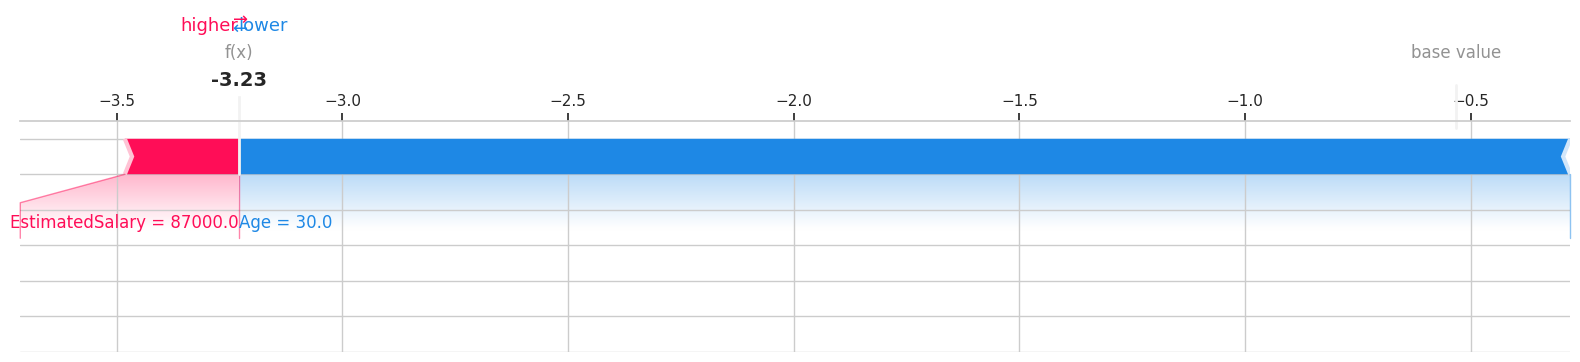

In [36]:
# CASO 1: Un acierto claro - el modelo predice bien
idx_acierto = aciertos[0]
print(f'=== ACIERTO: Observación {idx_acierto} ===')
print(f'Predicción: {y_pred_clf[idx_acierto]} | Real: {y_test_clf.values[idx_acierto]}')
print(f'Datos: Age={X_test_clf.values[idx_acierto][0]:.0f}, Salary={X_test_clf.values[idx_acierto][1]:.0f}')
shap.force_plot(explainer.expected_value, shap_values.values[idx_acierto], X_test_clf_display.iloc[idx_acierto], matplotlib=True)
plt.show()

=== ACIERTO: Observación 50 ===
Predicción: 1 | Real: 1
Datos: Age=57, Salary=122000


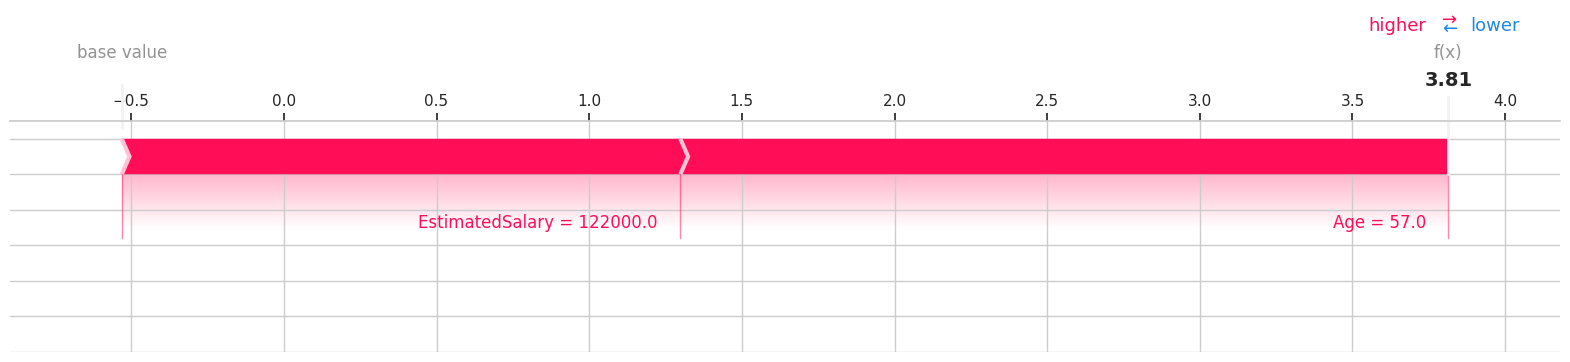

In [37]:
# CASO 2: Otro acierto con valores diferentes
idx_acierto2 = aciertos[len(aciertos)//2]  # cogemos uno del medio
print(f'=== ACIERTO: Observación {idx_acierto2} ===')
print(f'Predicción: {y_pred_clf[idx_acierto2]} | Real: {y_test_clf.values[idx_acierto2]}')
print(f'Datos: Age={X_test_clf.values[idx_acierto2][0]:.0f}, Salary={X_test_clf.values[idx_acierto2][1]:.0f}')
shap.force_plot(explainer.expected_value, shap_values.values[idx_acierto2], X_test_clf_display.iloc[idx_acierto2], matplotlib=True)
plt.show()

=== FALLO: Observación 9 ===
Predicción: 1 | Real: 0 ← EL MODELO SE EQUIVOCA
Datos: Age=47, Salary=43000


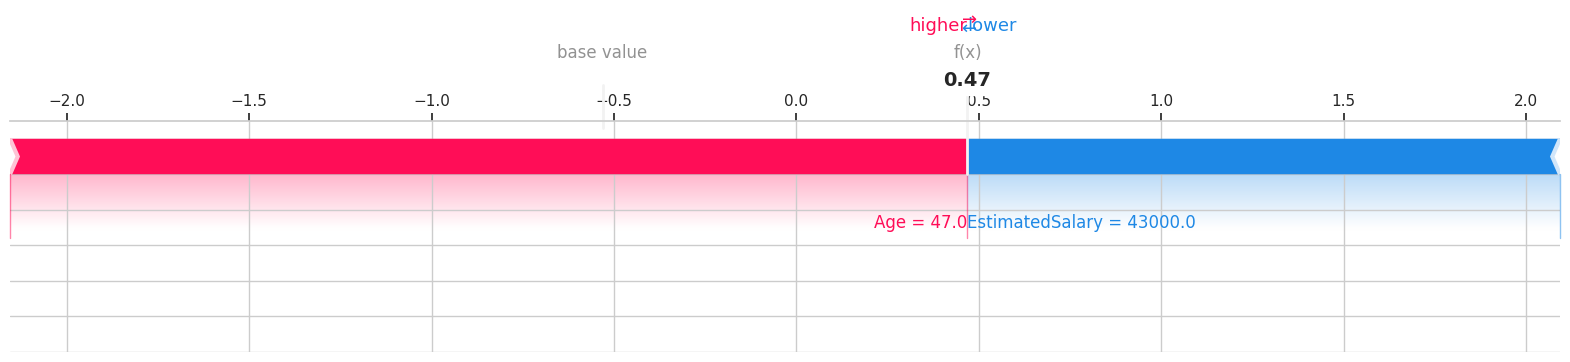


¿Por qué ha fallado? Mirando los valores SHAP podemos ver que las
variables empujaban en una direccion pero la realidad era la contraria.
Probablemente es un usuario con caracteristicas "fronterizas" donde
la decision no es clara.


In [38]:
# CASO 3: Un FALLO del modelo - aqui es donde SHAP es mas util
# Nos permite entender POR QUE el modelo se ha equivocado
if len(fallos) > 0:
    idx_fallo = fallos[0]
    print(f'=== FALLO: Observación {idx_fallo} ===')
    print(f'Predicción: {y_pred_clf[idx_fallo]} | Real: {y_test_clf.values[idx_fallo]} ← EL MODELO SE EQUIVOCA')
    print(f'Datos: Age={X_test_clf.values[idx_fallo][0]:.0f}, Salary={X_test_clf.values[idx_fallo][1]:.0f}')
    shap.force_plot(explainer.expected_value, shap_values.values[idx_fallo], X_test_clf_display.iloc[idx_fallo], matplotlib=True)
    plt.show()
    print()
    print('¿Por qué ha fallado? Mirando los valores SHAP podemos ver que las')
    print('variables empujaban en una direccion pero la realidad era la contraria.')
    print('Probablemente es un usuario con caracteristicas "fronterizas" donde')
    print('la decision no es clara.')
else:
    print('El modelo no ha cometido ningun fallo en el test (poco probable pero posible)')

### 3.1.2 Gráficos de dependencias (Dependence Plots)

Los dependence plots muestran la relación entre el valor de una variable y su impacto SHAP. Permiten ver cómo influye cada variable en la predicción a lo largo de su rango de valores.

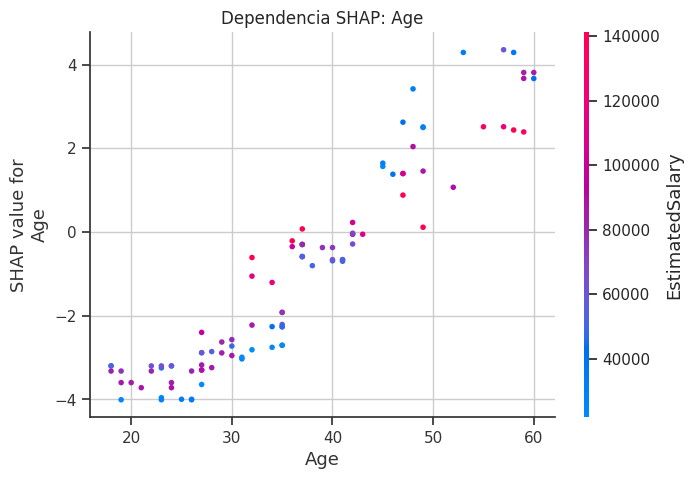

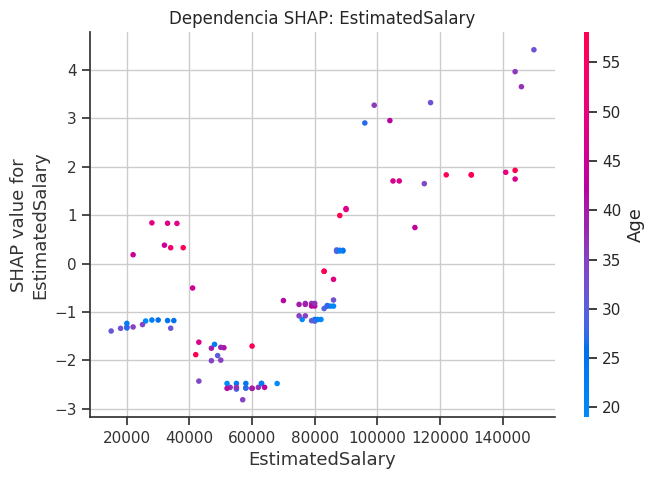

In [39]:
# Grafico de dependencia para cada variable
# Muestra como influye el valor de cada variable en la prediccion
# Parecido al interpret_model(catb, plot='correlation', feature=...) que vimos con PyCaret
for col in X_clf.columns:
    shap.dependence_plot(col, shap_values.values, X_test_clf_display, show=False)
    plt.title(f'Dependencia SHAP: {col}')
    plt.show()

### 3.1.3 Conclusiones - Predicción individual

Los gráficos de fuerza nos permiten entender **por qué** el modelo toma una decisión concreta para cada usuario. Esto es algo que con las métricas globales (accuracy, precision...) no podíamos hacer.

**¿Qué hemos visto?**
- Cuando un usuario tiene **edad alta y salario alto**, ambas variables empujan la predicción hacia "sí compra" (valores SHAP positivos). Esto tiene sentido: personas con más edad y más poder adquisitivo tienen más probabilidad de comprar productos anunciados en redes sociales.
- Cuando un usuario es **joven y con salario bajo**, ambas variables empujan hacia "no compra" (valores SHAP negativos). También es lógico: un estudiante de 20 años con poco salario tiene menos probabilidad de comprar.
- Los casos más interesantes son los **intermedios**: un usuario joven con salario alto, o uno mayor con salario bajo. Ahí vemos cómo las variables "compiten" entre sí, y el modelo pondera cuál tiene más peso.

**Los gráficos de dependencia** confirman estas relaciones:
- La relación entre Age y la predicción no es perfectamente lineal: hay un "salto" alrededor de los 35-40 años donde la probabilidad de compra sube significativamente.
- EstimatedSalary también tiene un efecto no lineal: a partir de cierto umbral de salario, la probabilidad de compra aumenta mucho.

Estas relaciones no lineales son precisamente lo que XGBoost captura bien y lo que una regresión logística simple no podría modelar con la misma precisión.

## 3.2 Explicar el dataset completo

### 3.2.1 Summary Plot

El summary plot es la visualización global más importante de SHAP. Muestra:
- **Eje Y:** Variables ordenadas por importancia (de arriba a abajo)
- **Eje X:** Valor SHAP (impacto en la predicción)
- **Color:** Valor de la variable (rojo = alto, azul = bajo)

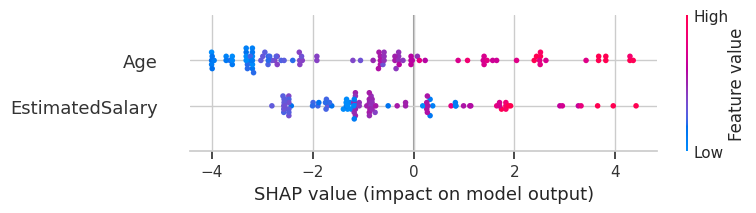

In [40]:
# Summary plot tipo beeswarm (el mas importante)
# Cada punto es una observacion, color rojo = valor alto, azul = valor bajo
# Parecido al interpret_model(catb) que vimos en clase con PyCaret
shap.summary_plot(shap_values.values, X_test_clf_display)

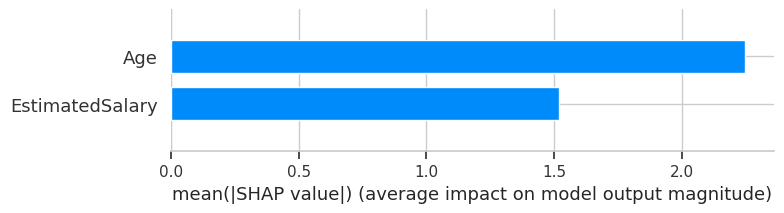

In [41]:
# Summary plot en formato de barras (importancia media de cada variable)
# Mas facil de leer que el beeswarm para ver rapidamente que variable pesa mas
shap.summary_plot(shap_values.values, X_test_clf_display, plot_type='bar')

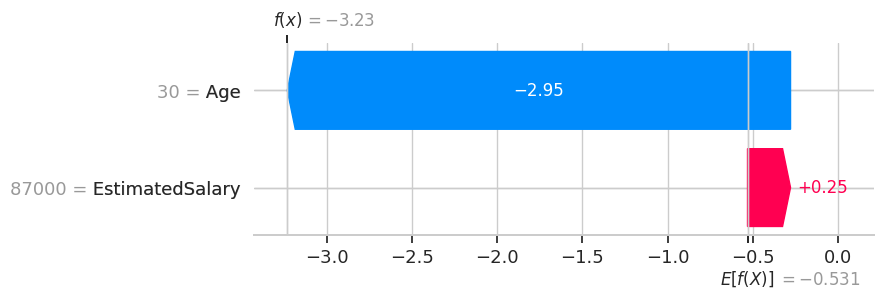

In [42]:
# Waterfall plot - muestra paso a paso como se construye la prediccion
# Partiendo del valor base, va sumando/restando la contribucion de cada variable
shap.waterfall_plot(shap_values[0])

### 3.2.2 Conclusiones - Dataset completo

Del análisis SHAP global del modelo XGBoost sobre el dataset Social Network Ads podemos concluir:

1. **Importancia de variables:** El summary plot nos muestra de un vistazo qué variable pesa más en las decisiones del modelo. Podemos ver si la edad del usuario influye más que su salario (o al revés) a la hora de predecir si comprará el producto.

2. **Dirección del impacto:** Los puntos rojos a la derecha nos dicen que valores altos de esa variable empujan hacia "sí compra", y los azules a la izquierda hacia "no compra". Esto nos permite entender la lógica del modelo: por ejemplo, si usuarios con mayor edad y mayor salario tienen más probabilidad de comprar.

3. **De caja negra a modelo explicable:** Sin SHAP, XGBoost es una "caja negra" que nos da un resultado pero no sabemos por qué. Con SHAP podemos justificar cada predicción. Esto es muy importante en la vida real: imagina que una empresa de marketing necesita explicar a su cliente *por qué* el modelo recomienda mostrar publicidad a un usuario concreto.

4. **Más allá de las métricas globales:** En la UT6 evaluamos los modelos solo con métricas como accuracy o precision. SHAP nos da un nivel de detalle mucho mayor: no solo sabemos *cuánto* acierta el modelo, sino *por qué* toma cada decisión.

---

# 4. Conclusiones finales

## ¿Qué hemos hecho en este trabajo?

Este trabajo conecta lo aprendido en la **UT5** (regresión), la **UT6** (clasificación) y la **UT9** (XGBoost, AutoML y SHAP). Hemos usado los mismos datasets de las prácticas anteriores para poder comparar resultados directamente.

## 4.1 Sobre XGBoost

XGBoost es un algoritmo de *gradient boosting* que construye muchos árboles de decisión, donde cada nuevo árbol intenta corregir los errores del anterior. Es como un equipo donde cada miembro se especializa en resolver lo que los demás fallan.

**En regresión (House Prices):**
- Obtuvimos un R² competitivo para predecir precios de vivienda. El modelo captura relaciones no lineales (por ejemplo, que tener garaje sube el precio, pero no de forma proporcional al número de plazas).
- En la UT5 ya vimos que los modelos ensemble (Random Forest, Stacking) superaban a la regresión lineal. XGBoost sigue esa misma línea: combinar varios modelos simples da mejor resultado que uno solo complejo.
- Hemos probado 3 configuraciones de hiperparámetros con validación cruzada para no quedarnos con valores por defecto sin justificar.

**En clasificación (Social Network Ads):**
- XGBoost alcanza un accuracy comparable a los mejores modelos de la UT6 (KNN y SVM RBF con 0.93).
- La ventaja de XGBoost sobre SVM es que es más interpretable (podemos ver la importancia de cada variable) y escala mejor a datasets grandes.

## 4.2 Sobre AutoML con FLAML

La idea de AutoML es sencilla: en vez de que nosotros probemos a mano diferentes algoritmos y configuraciones (como hicimos en la UT6 probando KNN, SVM, Naive Bayes, etc.), dejamos que un sistema automático lo haga por nosotros.

FLAML ha probado automáticamente múltiples algoritmos (Random Forest, XGBoost, LightGBM, Extra Trees...) y ha buscado los mejores hiperparámetros para cada uno, todo en 120 segundos. Lo que a nosotros nos llevó varias prácticas, FLAML lo hace en 2 minutos.

**¿Significa que AutoML reemplaza al data scientist?** No. AutoML automatiza la parte más mecánica (probar modelos), pero sigue siendo necesario:
- Entender el problema y elegir bien los datos
- Preparar y limpiar el dataset
- Interpretar los resultados (ahí es donde entra SHAP)

**Sobre la elección de FLAML:** El enunciado proponía auto-sklearn o PyCaret, pero ambas librerías son incompatibles con Python 3.12 (la versión actual de Google Colab). auto-sklearn fue abandonado en 2022 y PyCaret 3.3.2 bloquea explícitamente Python 3.12. FLAML de Microsoft es la alternativa más actual y funcional.

## 4.3 Sobre SHAP y la interpretabilidad

SHAP responde a la pregunta más importante en Machine Learning aplicado: **¿por qué el modelo ha tomado esta decisión?**

- Los **force plots** nos permiten explicar una predicción concreta, tanto aciertos como fallos. Hemos visto que cuando el modelo falla, SHAP nos ayuda a entender que el usuario tenía características "fronterizas" donde la decisión no era clara.
- Los **summary plots** nos dan la foto global: qué variables son las más importantes y cómo influyen en general.
- Los **dependence plots** muestran si la relación es lineal (a más edad, más compra) o tiene matices (compra más a partir de cierta edad, pero luego se estabiliza).

## 4.4 Sobre los datasets utilizados

| Dataset | Usado en | Problema | Objetivo |
|---|---|---|---|
| House Prices | UT5 y UT9 | Regresión | Predecir el precio de venta de una vivienda |
| Social Network Ads | UT6 y UT9 | Clasificación | Predecir si un usuario comprará un producto |

Ambos se descargan automáticamente desde Kaggle con `kagglehub`. El dataset de clasificación fue proporcionado en la UT6 como "Ensayo de Motores" con columnas renombradas (Age→RPM, EstimatedSalary→Par de carga), pero al descargarlo de Kaggle descubrí que es el dataset Social Network Ads original. He optado por usar los nombres originales porque tienen más sentido con los datos reales.

## 4.5 Resumen: evolución a lo largo del curso

| UT | Qué hicimos | Qué aprendimos |
|---|---|---|
| **UT5** | Regresión con varios modelos (Lineal, SVR, Random Forest) | A predecir valores numéricos y comparar modelos con RMSE y R² |
| **UT6** | Clasificación con 7 modelos diferentes (KNN, SVM, etc.) | A predecir categorías y evaluar con accuracy, precision, recall |
| **UT9** | XGBoost + FLAML AutoML + SHAP | Gradient boosting (mejor rendimiento), AutoML (automatizar la búsqueda) y SHAP (explicar las decisiones) |

La progresión es clara: primero aprendimos a entrenar modelos manualmente, luego a automatizar ese proceso con AutoML, y finalmente a explicar *por qué* los modelos toman las decisiones que toman. En un proyecto real de Machine Learning, las tres habilidades son necesarias.